# 1. 安装依赖并导入库

In [11]:
# 安装所需库（首次运行时执行）
#!pip install jieba numpy networkx matplotlib scikit-learn

# 导入库
import re
import jieba
import jieba.analyse
import jieba.posseg as pseg
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict

# 设置中文显示
plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC"]

# 2. 定义 TextRank 核心算法类

In [12]:
class TextRank:
    def __init__(self, d=0.85, iterations=200, tol=1e-6):
        """
        :param d: 阻尼系数（通常取0.85）
        :param iterations: 最大迭代次数
        :param tol: 收敛阈值（权重变化小于此值时停止迭代）
        """
        self.d = d
        self.iterations = iterations
        self.tol = tol
        self.graph = None  # 存储图结构
        self.weights = None  # 存储节点权重

    def _build_graph(self, nodes, relations):
        """构建无向图（节点+边权重）"""
        self.graph = nx.Graph()
        self.graph.add_nodes_from(nodes)
        for (u, v), weight in relations.items():
            self.graph.add_edge(u, v, weight=weight)

    def _calculate_weights(self):
        """计算节点权重（TextRank核心迭代公式）"""
        # 初始化权重：所有节点权重为1.0
        weights = {node: 1.0 for node in self.graph.nodes}
        nodes = list(self.graph.nodes)
        num_nodes = len(nodes)

        for _ in range(self.iterations):
            new_weights = {}
            max_diff = 0.0  # 记录权重最大变化值

            for node in nodes:
                # 计算相邻节点的贡献总和
                sum_contrib = 0.0
                neighbors = list(self.graph.neighbors(node))
                if not neighbors:
                    new_weights[node] = (1 - self.d)  # 无邻居节点的权重
                    continue

                for neighbor in neighbors:
                    # 邻居节点的出度权重和（无向图中为邻居的所有边权重和）
                    neighbor_degree = sum(self.graph[neighbor][n]['weight'] for n in self.graph.neighbors(neighbor))
                    if neighbor_degree == 0:
                        contrib = 0.0
                    else:
                        # 贡献 = 邻居权重 / 邻居的出度权重和 * 边权重
                        edge_weight = self.graph[node][neighbor]['weight']
                        contrib = weights[neighbor] * edge_weight / neighbor_degree
                    sum_contrib += contrib

                # 迭代公式：weight = (1-d) + d * sum(贡献)
                new_weight = (1 - self.d) + self.d * sum_contrib
                max_diff = max(max_diff, abs(new_weight - weights[node]))
                new_weights[node] = new_weight

            weights = new_weights
            # 如果权重变化小于阈值，提前停止迭代
            if max_diff < self.tol:
                break

        self.weights = weights
        return weights

    def extract_keywords(self, text, top_k=10, window_size=5, pos_filter=['n', 'v', 'a']):
        """
        提取关键词
        :param text: 输入文本
        :param top_k: 返回前k个关键词
        :param window_size: 共现窗口大小
        :param pos_filter: 保留的词性（n:名词, v:动词, a:形容词）
        :return: 排序后的关键词列表
        """
        # 1. 文本预处理：分词+词性标注+过滤
        # 使用 jieba.posseg（已在导入单元声明为 pseg），lcut 返回的每个元素为有 word/flag 属性的对象
        words_with_pos = pseg.lcut(text)  # 带词性的分词
        # 过滤停用词和非目标词性
        #stopwords = set(jieba.analyse.set_stop_words('stopwords.txt'))  # 可自行创建stopwords.txt
        stopwords = set()  # 简化示例，不使用停用词
        valid_words = []
        for w in words_with_pos:
            # jieba.posseg 返回的对象使用 .word 和 .flag 属性
            word = getattr(w, 'word', None)
            pos = getattr(w, 'flag', None)
            if word is None:
                continue
            if (word not in stopwords 
                and len(word) > 1 
                and pos is not None and any(pos.startswith(p) for p in pos_filter)):  # 匹配词性前缀
                valid_words.append(word)

        # 2. 构建共现关系（窗口内共现的词建立连接）
        relations = defaultdict(float)
        for i in range(len(valid_words)):
            # 窗口内的词与当前词共现
            for j in range(i+1, min(i+window_size, len(valid_words))):
                u = valid_words[i]
                v = valid_words[j]
                if u != v:
                    # 无向图，双向累加权重
                    relations[(u, v)] += 1.0
                    relations[(v, u)] += 1.0

        # 3. 构建图并计算权重
        self._build_graph(valid_words, relations)
        # 使用 number_of_nodes() 判断图是否为空，避免对 NodeView 做布尔判断导致异常
        if self.graph.number_of_nodes() == 0:
            return []
        weights = self._calculate_weights()

        # 4. 按权重排序并返回前k个
        sorted_keywords = sorted(weights.items(), key=lambda x: x[1], reverse=True)
        return sorted_keywords[:top_k]

    def extract_keysentences(self, text, top_k=3):
        """
        提取关键句（用于生成摘要）
        :param text: 输入文本
        :param top_k: 返回前k个关键句
        :return: 排序后的关键句列表
        """
        # 1. 拆分句子
        sentences = re.split(r'[。！？；,.!?;]', text)
        sentences = [s.strip() for s in sentences if s.strip()]  # 过滤空句
        if len(sentences) <= top_k:
            return sentences  # 句子数少于top_k时直接返回

        # 2. 句子向量化（简单词袋模型）
        # 收集所有词并去重
        all_words = []
        for s in sentences:
            all_words.extend(jieba.lcut(s))
        vocab = list(set(all_words))
        word2idx = {w: i for i, w in enumerate(vocab)}

        # 构建句子向量（词袋表示）
        sent_vectors = []
        for s in sentences:
            vec = np.zeros(len(vocab))
            for word in jieba.lcut(s):
                if word in word2idx:
                    vec[word2idx[word]] += 1
            sent_vectors.append(vec.reshape(1, -1))

        # 3. 计算句子相似度（余弦相似度）
        relations = defaultdict(float)
        for i in range(len(sentences)):
            for j in range(i+1, len(sentences)):
                sim = cosine_similarity(sent_vectors[i], sent_vectors[j])[0][0]
                if sim > 0:  # 只保留有相似度的连接
                    relations[(i, j)] = sim
                    relations[(j, i)] = sim

        # 4. 构建图并计算权重（用句子索引作为节点）
        self._build_graph(range(len(sentences)), relations)
        weights = self._calculate_weights()

        # 5. 按权重排序并返回对应句子
        sorted_sents = sorted(weights.items(), key=lambda x: x[1], reverse=True)
        return [sentences[idx] for idx, _ in sorted_sents[:top_k]]

    def visualize_graph(self, top_nodes=10):
        """可视化Top N节点的图结构（关键词或句子）"""
        if not self.graph or not self.weights:
            print("请先运行提取关键词或关键句")
            return

        # 筛选权重最高的节点
        top_nodes = sorted(self.weights.items(), key=lambda x: x[1], reverse=True)[:top_nodes]
        top_node_names = [n for n, _ in top_nodes]
        subgraph = self.graph.subgraph(top_node_names)

        # 绘图
        plt.figure(figsize=(12, 8))
        pos = nx.spring_layout(subgraph, seed=42)  # 布局算法
        # 节点大小与权重成正比
        node_sizes = [self.weights[n] * 1000 for n in subgraph.nodes]
        # 边的粗细与权重成正比
        edge_weights = [subgraph[u][v]['weight'] for u, v in subgraph.edges]

        nx.draw_networkx_nodes(subgraph, pos, node_size=node_sizes, node_color='lightblue')
        nx.draw_networkx_edges(subgraph, pos, width=edge_weights, edge_color='gray')
        nx.draw_networkx_labels(subgraph, pos, font_size=10)
        plt.title("TextRank Top节点关联图")
        plt.axis('off')
        plt.show()

# 3. 示例：使用 TextRank 提取关键词和关键句

===== 关键词提取结果 =====
1. 模型（权重：2.4864）
2. 语言（权重：1.7196）
3. 研究（权重：1.6482）
4. 文本（权重：1.5049）
5. 挑战（权重：1.0695）
6. 传播（权重：1.0284）
7. 偏见（权重：0.9965）
8. 计算机（权重：0.9940）


findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
/Users/hqyang/anaconda3/envs/py39/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/hqyang/anaconda3/envs/py39/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/hqyang/anaconda3/envs/py39/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 30740 (\N{CJK UNIFIED IDEOGRAPH-7814}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/hqyang/anaconda3/envs/py39/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 31350 (\N{CJK UNIFIED IDEOGRAP

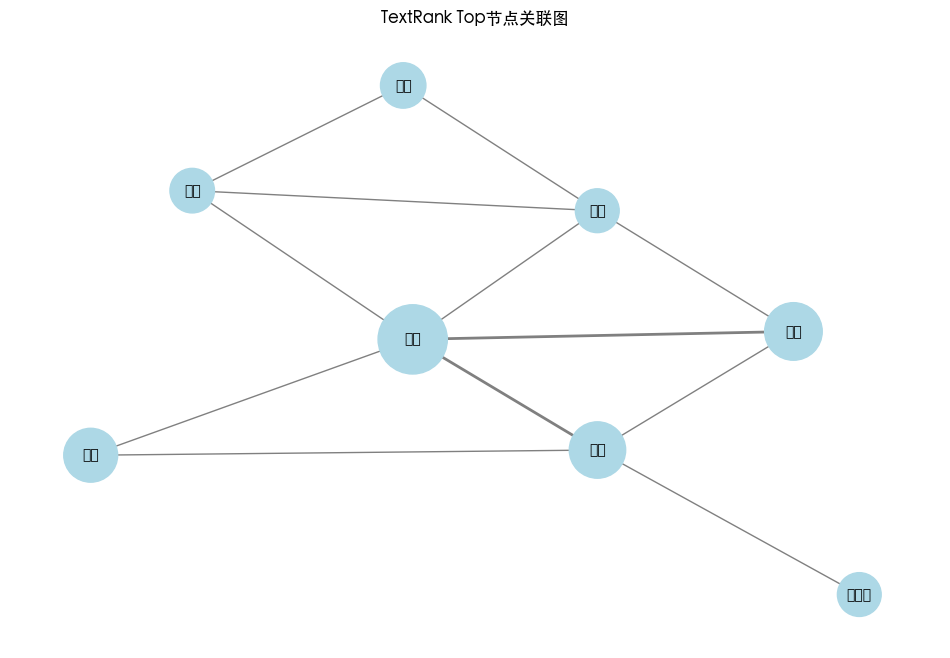


===== 关键句提取结果（摘要） =====
1. 近年来，随着深度学习的发展，大语言模型（如GPT、LLaMA）成为NLP领域的研究热点
2. 然而，大语言模型也面临数据隐私、偏见传播等挑战，未来需要在技术创新与伦理规范之间找到平衡


In [14]:
# 示例文本（可替换为自己的文本）
sample_text = """
自然语言处理（NLP）是人工智能的重要分支，它研究人与计算机之间的自然语言交互。
近年来，随着深度学习的发展，大语言模型（如GPT、LLaMA）成为NLP领域的研究热点。
这些模型通过海量文本训练，能够实现文本生成、机器翻译、情感分析等多种任务。
在实际应用中，NLP技术已广泛用于智能客服、搜索引擎、内容推荐等场景。
然而，大语言模型也面临数据隐私、偏见传播等挑战，未来需要在技术创新与伦理规范之间找到平衡。
"""

# 初始化TextRank模型
tr = TextRank(d=0.85, iterations=200)

# --------------------------
# 提取关键词
# --------------------------
print("===== 关键词提取结果 =====")
keywords = tr.extract_keywords(
    text=sample_text,
    top_k=8,
    window_size=5,  # 共现窗口大小为5
    pos_filter=['n', 'v']  # 保留名词和动词
)
for idx, (word, weight) in enumerate(keywords, 1):
    print(f"{idx}. {word}（权重：{weight:.4f}）")

# 可视化关键词关联图
tr.visualize_graph(top_nodes=8)

# --------------------------
# 提取关键句（生成摘要）
# --------------------------
print("\n===== 关键句提取结果（摘要） =====")
keysentences = tr.extract_keysentences(
    text=sample_text,
    top_k=2  # 提取2个关键句
)
for idx, sent in enumerate(keysentences, 1):
    print(f"{idx}. {sent}")